In [1]:
# Import necessary libraries
import scanpy as sc
import scipy.cluster.hierarchy as sch
from scipy.stats import spearmanr
import numpy as np
import pandas as pd

## Load scRNA-seq data
adata = sc.read_h5ad("/fs/cbsuvlaminck5/workdir/cjl332/scRNAseq_data/tabsap_v2/tabsap_v2.h5ad")
adata = adata[(adata.obs['disease'] == "normal") & (adata.obs['assay'] == "10x 3' v3")]

In [82]:
import matplotlib.pyplot as plt
import scanpy as sc

sc.set_figure_params(scanpy=True, fontsize=8)

# Define the cell types to highlight
vascular_endothelial = [
    "endothelial cell of vascular tree",
    "cardiac endothelial cell",
    "endothelial cell of artery",
    "vein endothelial cell",
    "capillary endothelial cel",
    "endothelial cell",
    "retinal blood vessel endothelial cell"
]

vascular_smoothmuscle = [
"pericyte",
"vascular associated smooth muscle cell"]

vascular_fibroblast = ["alveolar adventitial fibroblast","myofibroblast cell"]

# Precompute the number of cells in adata
n_cells = len(adata)

# Create a new column in adata.obs to store the color information
adata.obs['highlight'] = 'Other'

# Use a mask to optimize the .loc operation
mask1 = adata.obs['cell_type'].isin(vascular_endothelial)
mask2 = adata.obs['cell_type'].isin(vascular_smoothmuscle)
mask3 = adata.obs['cell_type'].isin(vascular_fibroblast)


adata.obs.loc[mask1, 'highlight'] = "vascular endothelial"
adata.obs.loc[mask2, 'highlight'] = "vascular smooth muscle"
adata.obs.loc[mask3, 'highlight'] = "vascular fibroblast"


# Ensure 'highlight' is categorical so Scanpy assigns colors
adata.obs['highlight'] = adata.obs['highlight'].astype('category')

# Define the size for the highlighted cell types
default_size = 12000 / n_cells
highlighted_size = default_size * 5

adata.obs['size'] = default_size
adata.obs.loc[mask1, 'size'] = highlighted_size
adata.obs.loc[mask2, 'size'] = highlighted_size
adata.obs.loc[mask3, 'size'] = highlighted_size

/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


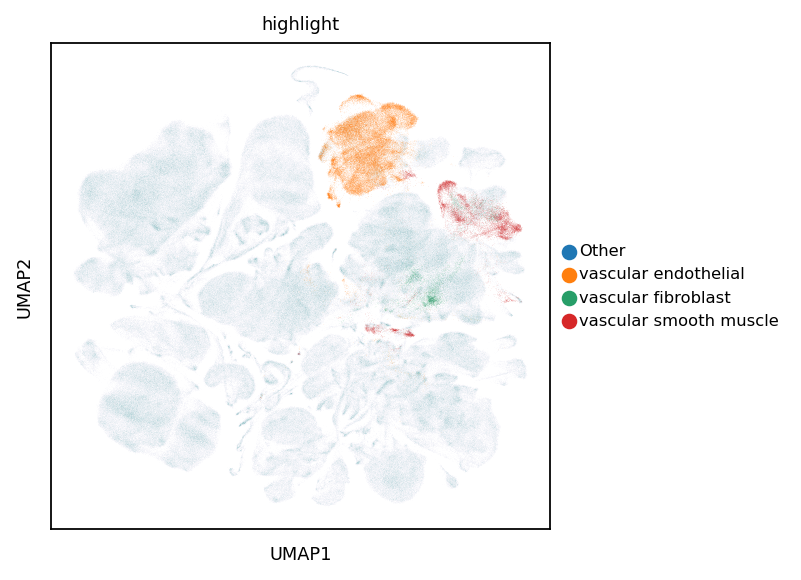

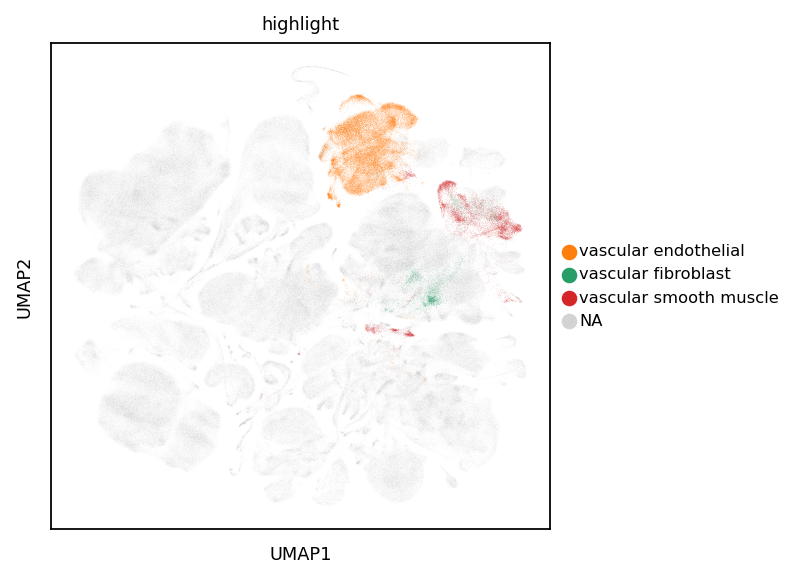

/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


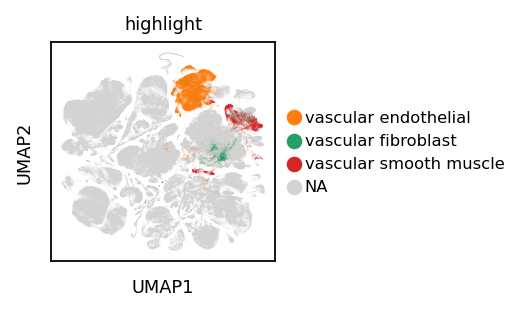

In [ ]:
# Plot once to trigger color assignment in adata.uns
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values, show=False)

# Now we can safely remove 'Other' from the color list
highlight_colors = adata.uns['highlight_colors']
categories = adata.obs['highlight'].cat.categories
filtered_colors = [color for label, color in zip(categories, highlight_colors) if label != 'Other']
adata.uns['highlight_colors'] = filtered_colors

# Filter categories so 'Other' is not shown in legend
adata.obs['highlight'] = adata.obs['highlight'].cat.remove_categories(['Other'])

# Final plot
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values)

# Save as high-resolution PNG
fig, ax = plt.subplots(figsize=(1.8, 1.8))
sc.pl.umap(adata, color='highlight', size=adata.obs['size'].values, ax=ax, show=False)
plt.savefig('./umap_highlighted_cells.png', dpi=300, bbox_inches='tight')

/home/cjl332/miniconda3/envs/tabsap/lib/python3.10/site-packages/anndata/_core/anndata.py:1295: FutureWarning: In a future version of AnnData, access to `.X` by passing `layer='X'` will be removed. Instead pass `layer=None`.
  warnings.warn(


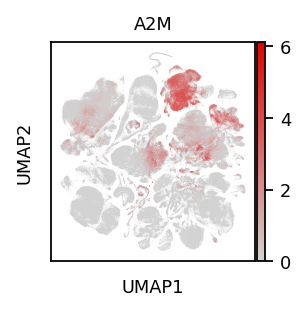

In [ ]:
import seaborn as sns

GENE = "A2M"

sc.set_figure_params(scanpy=True, fontsize=8)

# Save the updated UMAP plot as a high-resolution PNG
fig, ax = plt.subplots(figsize=(1.8, 1.8))

sc.pl.umap(adata, 
        color=GENE,
        gene_symbols = "feature_name", 
        layer = "X",
        legend_fontsize = 6,
        size=adata.obs['size'].values, 
        cmap=sns.blend_palette(["lightgray", sns.xkcd_rgb["red"]], as_cmap=True), 
        ax=ax, show=False)

plt.xlabel('UMAP1', size = 8)
plt.ylabel('UMAP2', size = 8)

plt.savefig("./template_umap_"+GENE+'.png', dpi=300, bbox_inches='tight')